# Insulin Resistance Detection Using Machine Learning


# Exploratory Data Analysis (EDA)

## 2. Dataset Explanation

We will use a medical dataset to predict whether a person has insulin resistance.

The target column is:

* `Insulin_Resistance`: `1` means the person has insulin resistance, `0` means the person does not have insulin resistance.

The target will be derived from the `HOMA_IR` value.

### Important Feature Columns

| Column              | Meaning                                                  |
| :------------------ | :------------------------------------------------------- |
| `patient_id`        | Unique patient identifier                                |
| `age`               | Patient age in years                                     |
| `gender`            | Patient gender                                           |
| `BMI`               | Body Mass Index                                          |
| `fasting_glucose`   | Fasting blood glucose level                              |
| `HbA1c`             | Average blood glucose level over the previous 2–3 months |
| `insulin`           | Blood insulin level                                      |
| `HOMA_IR`           | Homeostatic Model Assessment of Insulin Resistance       |
| `triglycerides`     | Level of triglycerides in the blood                      |
| `HDL`               | High-Density Lipoprotein cholesterol                     |
| `LDL`               | Low-Density Lipoprotein cholesterol                      |
| `blood_pressure`    | Patient blood pressure                                   |
| `physical_activity` | Level of physical activity                               |


##  Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


##  Load Data

In [2]:
df = pd.read_csv(r"C:\Users\A7maD Elsa3danY\Desktop\Project\research_grade_type2_diabetes_dataset_v3.csv")
df

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity
0,1,25,Male,22.705471,93.193330,4.716758,8.183787,1.671935,204.377524,38.688426,146.210743,157.355796,medium
1,1,26,Male,22.192149,86.949074,4.827949,8.676000,2.082398,198.232672,38.421221,134.459133,132.386041,medium
2,1,27,Male,22.901595,84.985529,4.905558,11.422285,2.698112,207.528255,25.085364,92.051616,119.068184,medium
3,1,28,Male,25.735394,92.706466,5.040370,10.809908,3.040924,173.709192,21.472752,104.451246,144.497555,medium
4,1,29,Male,26.018584,97.207901,4.867005,13.050991,3.573753,218.973728,22.834199,128.345299,132.225836,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
496357,10000,73,Male,16.376022,70.000000,4.066202,40.000000,5.000000,146.337661,30.210842,117.471310,129.427655,high
496358,10000,74,Male,16.824483,84.175095,4.087399,40.000000,5.000000,164.756232,36.312770,109.315448,139.175676,high
496359,10000,75,Male,17.818869,70.000000,4.066202,40.000000,5.000000,219.160729,34.603686,113.038049,112.565008,high
496360,10000,76,Male,16.187347,76.535249,4.084601,40.000000,5.000000,197.742454,56.884551,106.022895,120.852448,high


In [3]:
# Show the first rows
display(df.head())

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity
0,1,25,Male,22.705471,93.193330,4.716758,8.183787,1.671935,204.377524,38.688426,146.210743,157.355796,medium
1,1,26,Male,22.192149,86.949074,4.827949,8.676000,2.082398,198.232672,38.421221,134.459133,132.386041,medium
2,1,27,Male,22.901595,84.985529,4.905558,11.422285,2.698112,207.528255,25.085364,92.051616,119.068184,medium
3,1,28,Male,25.735394,92.706466,5.040370,10.809908,3.040924,173.709192,21.472752,104.451246,144.497555,medium
4,1,29,Male,26.018584,97.207901,4.867005,13.050991,3.573753,218.973728,22.834199,128.345299,132.225836,medium


In [4]:
# Show the last rows
display(df.tail(10))

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity
496352,10000,68,Male,12.077928,76.284208,4.066202,34.876505,5.0,187.410112,40.954690,98.058087,128.872837,high
496353,10000,69,Male,15.217449,73.873902,4.066202,36.384843,5.0,216.823107,36.128864,101.353825,145.294431,high
496354,10000,70,Male,14.350919,79.692611,4.066202,39.809470,5.0,166.932600,44.040434,111.985522,111.497601,high
496355,10000,71,Male,14.184640,70.000000,4.066202,40.000000,5.0,174.756929,30.582622,130.325098,123.507861,high
496356,10000,72,Male,15.672831,70.000000,4.068000,35.409724,5.0,187.886790,48.180480,142.834641,133.816196,high
496357,10000,73,Male,16.376022,70.000000,4.066202,40.000000,5.0,146.337661,30.210842,117.471310,129.427655,high
496358,10000,74,Male,16.824483,84.175095,4.087399,40.000000,5.0,164.756232,36.312770,109.315448,139.175676,high
496359,10000,75,Male,17.818869,70.000000,4.066202,40.000000,5.0,219.160729,34.603686,113.038049,112.565008,high
496360,10000,76,Male,16.187347,76.535249,4.084601,40.000000,5.0,197.742454,56.884551,106.022895,120.852448,high
496361,10000,77,Male,17.586216,73.089192,4.066202,39.222655,5.0,205.042701,49.505127,133.865343,120.344806,high


In [5]:
# Show random rows
display(df.sample(5, random_state=47))

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity
353275,7119,74,Female,29.193973,157.652170,7.412887,38.810829,5.000000,207.863333,36.734834,103.445622,105.219497,medium
98550,1986,44,Male,21.582536,85.413641,5.079149,12.722348,3.765221,239.090575,34.743048,111.544038,130.272224,medium
433622,8737,71,Female,24.299909,116.736207,3.830774,16.337104,5.000000,210.852166,29.688053,112.396790,141.094750,medium
248900,5015,60,Female,33.701350,121.757142,5.720711,20.472056,5.000000,223.433507,30.119674,153.553875,150.829951,low
422614,8516,52,Male,23.502693,87.794073,3.596078,12.213188,4.283928,214.942571,47.933053,134.504136,150.400907,low


## 3. Creating the Insulin Resistance Target

To build a binary classification model, we need to create a target variable that indicates whether a person has insulin resistance.

The `HOMA_IR` value will be used to define the target.

For this project, a HOMA-IR cutoff of **2.5** is used as an operational threshold:

* `HOMA_IR < 3` → `0` → No Insulin Resistance
* `HOMA_IR >= 3` → `1` → Insulin Resistance

After creating the target, `HOMA_IR` will be removed from the model features to prevent data leakage.


In [6]:
# Define the HOMA-IR cutoff
HOMA_IR_CUTOFF = 3


# Create the target variable
df["Insulin_Resistance"] = (
    df["HOMA_IR"] >= HOMA_IR_CUTOFF
).astype(int)

# Display the first 10 rows
display(df[["HOMA_IR", "Insulin_Resistance"]].head(10))

,HOMA_IR,Insulin_Resistance
0,1.671935,0
1,2.082398,0
2,2.698112,0
3,3.040924,1
4,3.573753,1
5,4.484642,1
6,4.999885,1
7,5.000000,1
8,5.000000,1
9,5.000000,1


In [7]:
# Check the target distribution
print("Insulin Resistance Distribution:")
print(df["Insulin_Resistance"].value_counts())

print("\nPercentage Distribution:")
print(
    df["Insulin_Resistance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Insulin Resistance Distribution:
Insulin_Resistance
1    418472
0     77890
Name: count, dtype: int64

Percentage Distribution:
Insulin_Resistance
1    84.31
0    15.69
Name: proportion, dtype: float64


In [8]:
# Show the first rows
display(df.head())

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity,Insulin_Resistance
0,1,25,Male,22.705471,93.193330,4.716758,8.183787,1.671935,204.377524,38.688426,146.210743,157.355796,medium,0
1,1,26,Male,22.192149,86.949074,4.827949,8.676000,2.082398,198.232672,38.421221,134.459133,132.386041,medium,0
2,1,27,Male,22.901595,84.985529,4.905558,11.422285,2.698112,207.528255,25.085364,92.051616,119.068184,medium,0
3,1,28,Male,25.735394,92.706466,5.040370,10.809908,3.040924,173.709192,21.472752,104.451246,144.497555,medium,1
4,1,29,Male,26.018584,97.207901,4.867005,13.050991,3.573753,218.973728,22.834199,128.345299,132.225836,medium,1


In [9]:
# Show the last rows
display(df.tail(10))

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity,Insulin_Resistance
496352,10000,68,Male,12.077928,76.284208,4.066202,34.876505,5.0,187.410112,40.954690,98.058087,128.872837,high,1
496353,10000,69,Male,15.217449,73.873902,4.066202,36.384843,5.0,216.823107,36.128864,101.353825,145.294431,high,1
496354,10000,70,Male,14.350919,79.692611,4.066202,39.809470,5.0,166.932600,44.040434,111.985522,111.497601,high,1
496355,10000,71,Male,14.184640,70.000000,4.066202,40.000000,5.0,174.756929,30.582622,130.325098,123.507861,high,1
496356,10000,72,Male,15.672831,70.000000,4.068000,35.409724,5.0,187.886790,48.180480,142.834641,133.816196,high,1
496357,10000,73,Male,16.376022,70.000000,4.066202,40.000000,5.0,146.337661,30.210842,117.471310,129.427655,high,1
496358,10000,74,Male,16.824483,84.175095,4.087399,40.000000,5.0,164.756232,36.312770,109.315448,139.175676,high,1
496359,10000,75,Male,17.818869,70.000000,4.066202,40.000000,5.0,219.160729,34.603686,113.038049,112.565008,high,1
496360,10000,76,Male,16.187347,76.535249,4.084601,40.000000,5.0,197.742454,56.884551,106.022895,120.852448,high,1
496361,10000,77,Male,17.586216,73.089192,4.066202,39.222655,5.0,205.042701,49.505127,133.865343,120.344806,high,1


In [10]:
# Show random rows
display(df.sample(5, random_state=47))

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity,Insulin_Resistance
353275,7119,74,Female,29.193973,157.652170,7.412887,38.810829,5.000000,207.863333,36.734834,103.445622,105.219497,medium,1
98550,1986,44,Male,21.582536,85.413641,5.079149,12.722348,3.765221,239.090575,34.743048,111.544038,130.272224,medium,1
433622,8737,71,Female,24.299909,116.736207,3.830774,16.337104,5.000000,210.852166,29.688053,112.396790,141.094750,medium,1
248900,5015,60,Female,33.701350,121.757142,5.720711,20.472056,5.000000,223.433507,30.119674,153.553875,150.829951,low,1
422614,8516,52,Male,23.502693,87.794073,3.596078,12.213188,4.283928,214.942571,47.933053,134.504136,150.400907,low,1


##  Basic Dataset Inspection

In [11]:
# Check dataset shape
rows, columns = df.shape

print(f"Rows: {rows}")
print(f"Columns: {columns}")

Rows: 496362
Columns: 14


In [12]:
df.shape

(496362, 14)

In [13]:
# Display column names
print(df.columns.tolist())


['patient_id', 'age', 'gender', 'BMI', 'fasting_glucose', 'HbA1c', 'insulin', 'HOMA_IR', 'triglycerides', 'HDL', 'LDL', 'blood_pressure', 'physical_activity', 'Insulin_Resistance']


In [14]:
# Display data types
display(df.dtypes)

patient_id              int64
age                     int64
gender                 object
BMI                   float64
fasting_glucose       float64
HbA1c                 float64
insulin               float64
HOMA_IR               float64
triglycerides         float64
HDL                   float64
LDL                   float64
blood_pressure        float64
physical_activity      object
Insulin_Resistance      int64
dtype: object

In [15]:
# Show full dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496362 entries, 0 to 496361
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   patient_id          496362 non-null  int64  
 1   age                 496362 non-null  int64  
 2   gender              496362 non-null  object 
 3   BMI                 496362 non-null  float64
 4   fasting_glucose     496362 non-null  float64
 5   HbA1c               496362 non-null  float64
 6   insulin             496362 non-null  float64
 7   HOMA_IR             496362 non-null  float64
 8   triglycerides       496362 non-null  float64
 9   HDL                 496362 non-null  float64
 10  LDL                 496362 non-null  float64
 11  blood_pressure      496362 non-null  float64
 12  physical_activity   496362 non-null  object 
 13  Insulin_Resistance  496362 non-null  int64  
dtypes: float64(9), int64(3), object(2)
memory usage: 53.0+ MB


##  Descriptive Statistics

In [16]:
# Describe numerical columns
display(df.describe())

,patient_id,age,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,Insulin_Resistance
count,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000,496362.000000
mean,5000.637108,53.861823,26.038696,111.861525,5.458630,24.271347,4.347268,206.158900,36.108190,126.069844,136.089429,0.843078
std,2887.115811,15.751673,6.056667,38.072134,1.359982,10.444956,1.041476,28.364016,7.670278,16.143505,16.181801,0.363727
min,1.000000,19.000000,11.194870,70.000000,1.991637,2.000000,0.500000,84.586431,14.014540,52.767814,80.000000,0.000000
25%,2500.000000,41.000000,22.089613,83.307439,4.495347,15.541778,3.809740,186.914475,30.853666,115.172082,125.146610,1.000000
50%,5001.000000,54.000000,25.699361,100.809617,5.059671,23.436491,5.000000,206.021001,36.096602,126.023708,136.051192,1.000000
75%,7502.000000,66.000000,29.778993,131.729254,6.151545,33.643087,5.000000,225.210205,41.313727,136.959703,146.981457,1.000000
max,10000.000000,90.000000,50.445105,250.000000,12.000000,40.000000,5.000000,341.115193,71.406962,219.619451,200.000000,1.000000


In [17]:
# Count unique values in each column
display(df.nunique().sort_values())

gender                     2
Insulin_Resistance         2
physical_activity          3
age                       72
patient_id             10000
HOMA_IR               185437
fasting_glucose       447627
insulin               448485
HbA1c                 460927
HDL                   491735
blood_pressure        496025
LDL                   496148
triglycerides         496231
BMI                   496297
dtype: int64

## 7. Missing Values

In [18]:
# Count missing values
missing_count = df.isnull().sum()
display(missing_count)

patient_id            0
age                   0
gender                0
BMI                   0
fasting_glucose       0
HbA1c                 0
insulin               0
HOMA_IR               0
triglycerides         0
HDL                   0
LDL                   0
blood_pressure        0
physical_activity     0
Insulin_Resistance    0
dtype: int64

Duplicate Rows

In [19]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


##  Feature Preparation

In [20]:
# Encode gender

df["gender_encoded"] = df["gender"].map({
    "Female": 0,
    "Male": 1
})

In [21]:
display(df[["gender", "gender_encoded"]].head())

,gender,gender_encoded
0,Male,1
1,Male,1
2,Male,1
3,Male,1
4,Male,1


In [22]:
# Encode physical activity

df["physical_activity_encoded"] = df["physical_activity"].map({
    "low": 0,
    "medium": 1,
    "high": 2
})

In [23]:
display(df[["physical_activity", "physical_activity_encoded"]].head(5))

,physical_activity,physical_activity_encoded
0,medium,1
1,medium,1
2,medium,1
3,medium,1
4,medium,1


In [24]:
# Display data types
display(df.dtypes)

patient_id                     int64
age                            int64
gender                        object
BMI                          float64
fasting_glucose              float64
HbA1c                        float64
insulin                      float64
HOMA_IR                      float64
triglycerides                float64
HDL                          float64
LDL                          float64
blood_pressure               float64
physical_activity             object
Insulin_Resistance             int64
gender_encoded                 int64
physical_activity_encoded      int64
dtype: object

##  Feature Engineering


In [25]:
# Create Cholesterol Ratio feature

df["cholesterol_ratio"] = (
    df["LDL"] / df["HDL"]
)

display(
    df[["LDL", "HDL", "cholesterol_ratio"]].head(10)
)

,LDL,HDL,cholesterol_ratio
0,146.210743,38.688426,3.779186
1,134.459133,38.421221,3.499606
2,92.051616,25.085364,3.669535
3,104.451246,21.472752,4.864362
4,128.345299,22.834199,5.620749
5,129.940279,29.327638,4.430642
6,134.731644,32.133533,4.192867
7,122.067815,33.228378,3.673601
8,113.081190,29.595836,3.820848
9,141.361974,31.208333,4.529623


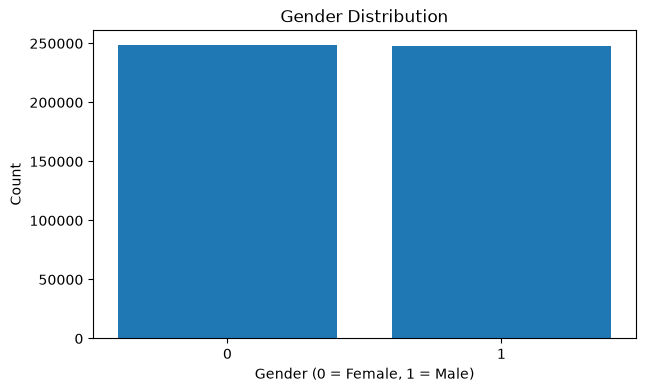

In [26]:
# Bar chart: Gender distribution

gender_counts = df["gender_encoded"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(gender_counts.index.astype(str), gender_counts.values)

plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.show()

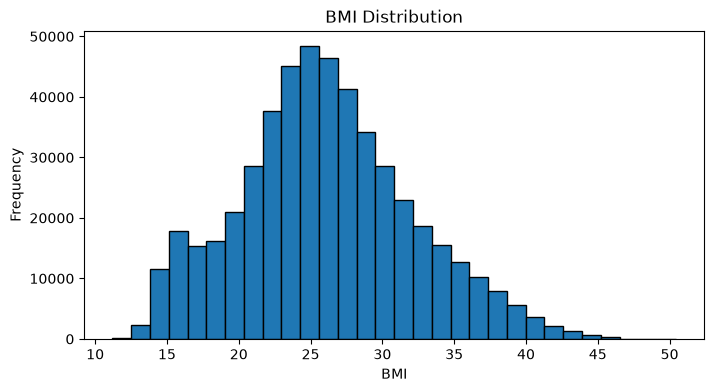

In [27]:
# Histogram: BMI distribution

plt.figure(figsize=(8, 4))
plt.hist(df["BMI"], bins=30, edgecolor="black")

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

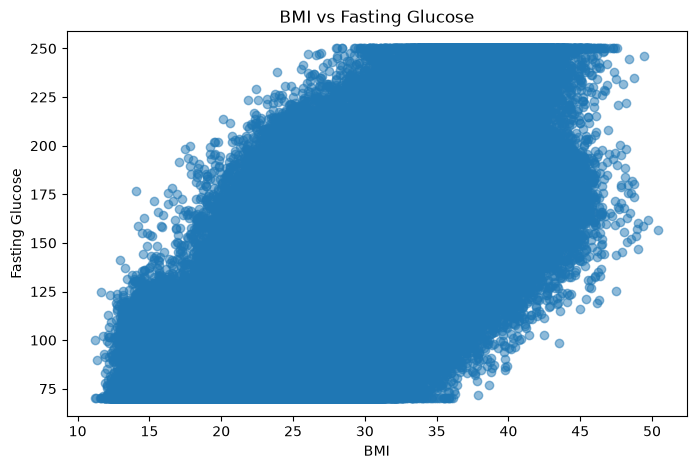

In [28]:
# Scatter plot: BMI vs Fasting Glucose

plt.figure(figsize=(8, 5))
plt.scatter(df["BMI"], df["fasting_glucose"], alpha=0.5)

plt.title("BMI vs Fasting Glucose")
plt.xlabel("BMI")
plt.ylabel("Fasting Glucose")

plt.show()

## 15. Correlation Analysis


In [29]:
# Correlation matrix after feature preparation

correlation_columns = [
    "Insulin_Resistance",
    "age",
    "BMI",
    "fasting_glucose",
    "HbA1c",
    "insulin",
    "triglycerides",
    "blood_pressure",
    
    
    "cholesterol_ratio"
]

corr_matrix = df[correlation_columns].corr()

display(corr_matrix)

,Insulin_Resistance,age,BMI,fasting_glucose,HbA1c,insulin,triglycerides,blood_pressure,cholesterol_ratio
Insulin_Resistance,1.000000,0.495437,0.221454,0.314643,0.261826,0.581685,0.096208,0.085087,0.112785
age,0.495437,1.000000,0.264915,0.463107,0.417329,0.648157,0.111489,0.097231,0.145139
BMI,0.221454,0.264915,1.000000,0.695308,0.656198,0.207304,0.410508,0.359095,0.460910
fasting_glucose,0.314643,0.463107,0.695308,1.000000,0.929680,0.566001,0.303931,0.265983,0.348961
HbA1c,0.261826,0.417329,0.656198,0.929680,1.000000,0.524364,0.287280,0.251400,0.330772
insulin,0.581685,0.648157,0.207304,0.566001,0.524364,1.000000,0.085543,0.076919,0.112644
triglycerides,0.096208,0.111489,0.410508,0.303931,0.287280,0.085543,1.000000,0.158953,0.201789
blood_pressure,0.085087,0.097231,0.359095,0.265983,0.251400,0.076919,0.158953,1.000000,0.177280
cholesterol_ratio,0.112785,0.145139,0.460910,0.348961,0.330772,0.112644,0.201789,0.177280,1.000000


In [30]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'BMI', 'fasting_glucose', 'HbA1c', 'insulin', 'HOMA_IR', 'triglycerides', 'HDL', 'LDL', 'blood_pressure', 'physical_activity', 'Insulin_Resistance', 'gender_encoded', 'physical_activity_encoded', 'cholesterol_ratio']


In [31]:
# Correlation matrix after feature preparation

correlation_columns = [
    "Insulin_Resistance",
    "age",
    "BMI",
    "fasting_glucose",
    "HbA1c",
    "insulin",
    "triglycerides",
    "blood_pressure",
    "gender_encoded",
    "physical_activity_encoded",
    "cholesterol_ratio"
]

corr_matrix = df[correlation_columns].corr()

display(corr_matrix)

,Insulin_Resistance,age,BMI,fasting_glucose,HbA1c,insulin,triglycerides,blood_pressure,gender_encoded,physical_activity_encoded,cholesterol_ratio
Insulin_Resistance,1.000000,0.495437,0.221454,0.314643,0.261826,0.581685,0.096208,0.085087,-0.000596,-0.117788,0.112785
age,0.495437,1.000000,0.264915,0.463107,0.417329,0.648157,0.111489,0.097231,0.001881,0.017001,0.145139
BMI,0.221454,0.264915,1.000000,0.695308,0.656198,0.207304,0.410508,0.359095,-0.011506,-0.705369,0.460910
fasting_glucose,0.314643,0.463107,0.695308,1.000000,0.929680,0.566001,0.303931,0.265983,-0.010459,-0.512919,0.348961
HbA1c,0.261826,0.417329,0.656198,0.929680,1.000000,0.524364,0.287280,0.251400,-0.009680,-0.482790,0.330772
insulin,0.581685,0.648157,0.207304,0.566001,0.524364,1.000000,0.085543,0.076919,0.001148,0.009946,0.112644
triglycerides,0.096208,0.111489,0.410508,0.303931,0.287280,0.085543,1.000000,0.158953,-0.005108,-0.316474,0.201789
blood_pressure,0.085087,0.097231,0.359095,0.265983,0.251400,0.076919,0.158953,1.000000,-0.006831,-0.276972,0.177280
gender_encoded,-0.000596,0.001881,-0.011506,-0.010459,-0.009680,0.001148,-0.005108,-0.006831,1.000000,0.012191,-0.004286
physical_activity_encoded,-0.117788,0.017001,-0.705369,-0.512919,-0.482790,0.009946,-0.316474,-0.276972,0.012191,1.000000,-0.343928


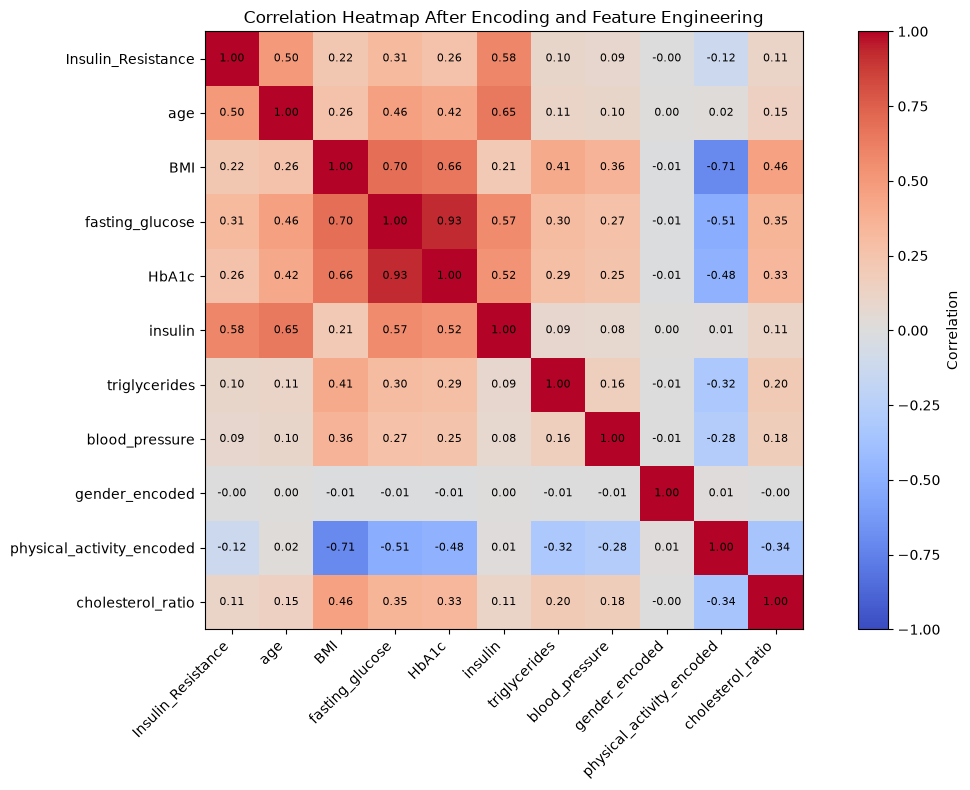

In [32]:
# Correlation heatmap after feature preparation

correlation_columns = [
    "Insulin_Resistance",
    "age",
    "BMI",
    "fasting_glucose",
    "HbA1c",
    "insulin",
    "triglycerides",
    "blood_pressure",
    "gender_encoded",
    "physical_activity_encoded",
    "cholesterol_ratio"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap After Encoding and Feature Engineering")

plt.tight_layout()
plt.show()

## . Outlier Detection

In [33]:
# Show the first rows
display(df.head(20))

,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity,Insulin_Resistance,gender_encoded,physical_activity_encoded,cholesterol_ratio
0,1,25,Male,22.705471,93.193330,4.716758,8.183787,1.671935,204.377524,38.688426,146.210743,157.355796,medium,0,1,1,3.779186
1,1,26,Male,22.192149,86.949074,4.827949,8.676000,2.082398,198.232672,38.421221,134.459133,132.386041,medium,0,1,1,3.499606
2,1,27,Male,22.901595,84.985529,4.905558,11.422285,2.698112,207.528255,25.085364,92.051616,119.068184,medium,0,1,1,3.669535
3,1,28,Male,25.735394,92.706466,5.040370,10.809908,3.040924,173.709192,21.472752,104.451246,144.497555,medium,1,1,1,4.864362
4,1,29,Male,26.018584,97.207901,4.867005,13.050991,3.573753,218.973728,22.834199,128.345299,132.225836,medium,1,1,1,5.620749
5,1,30,Male,22.261615,81.088724,4.979955,16.347518,4.484642,192.237706,29.327638,129.940279,146.671709,medium,1,1,1,4.430642
6,1,31,Male,22.562283,105.605470,5.066008,19.603192,4.999885,185.711550,32.133533,134.731644,130.033926,medium,1,1,1,4.192867
7,1,32,Male,24.298405,73.229131,4.197317,21.588242,5.000000,162.066891,33.228378,122.067815,121.574652,medium,1,1,1,3.673601
8,1,33,Male,26.146509,89.565842,4.961618,20.028411,5.000000,218.604883,29.595836,113.081190,146.308344,medium,1,1,1,3.820848
9,1,34,Male,23.572269,74.133163,3.632945,26.660365,5.000000,182.335317,31.208333,141.361974,141.334234,medium,1,1,1,4.529623


In [34]:
# Explore BMI before outlier detection

display(df["BMI"].describe())

count    496362.000000
mean         26.038696
std           6.056667
min          11.194870
25%          22.089613
50%          25.699361
75%          29.778993
max          50.445105
Name: BMI, dtype: float64

C:\Users\A7maD Elsa3danY\AppData\Local\Temp\ipykernel_7188\515859314.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["BMI"], vert=False)


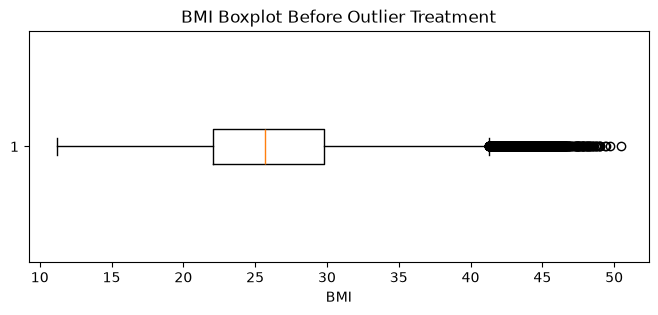

In [35]:
# BMI boxplot before outlier treatment

plt.figure(figsize=(8, 3))
plt.boxplot(df["BMI"], vert=False)
plt.title("BMI Boxplot Before Outlier Treatment")
plt.xlabel("BMI")
plt.show()

###  Method 1: IQR Method

In [36]:
# Detect BMI outliers using the IQR method

Q1_BMI = df["BMI"].quantile(0.25)
Q3_BMI = df["BMI"].quantile(0.75)

IQR_BMI = Q3_BMI - Q1_BMI

BMI_lower_iqr = Q1_BMI - 1.5 * IQR_BMI
BMI_upper_iqr = Q3_BMI + 1.5 * IQR_BMI

BMI_outliers_iqr = df[
    (df["BMI"] < BMI_lower_iqr) |
    (df["BMI"] > BMI_upper_iqr)
]

print("Q1:", Q1_BMI)
print("Q3:", Q3_BMI)
print("IQR:", IQR_BMI)
print("Lower bound:", BMI_lower_iqr)
print("Upper bound:", BMI_upper_iqr)
print("Outlier count:", len(BMI_outliers_iqr))
print("Outlier percentage:", round(len(BMI_outliers_iqr) / len(df) * 100, 2))

Q1: 22.0896132225
Q3: 29.77899284
IQR: 7.689379617500002
Lower bound: 10.555543796249996
Upper bound: 41.31306226625
Outlier count: 4373
Outlier percentage: 0.88


### 16.3 Method 2: Standard Deviation Method

In [37]:
# Detect BMI outliers using Mean ± 3 Standard Deviations

BMI_mean = df["BMI"].mean()
BMI_std = df["BMI"].std()

BMI_lower_sd = BMI_mean - 3 * BMI_std
BMI_upper_sd = BMI_mean + 3 * BMI_std

BMI_outliers_sd = df[
    (df["BMI"] < BMI_lower_sd) |
    (df["BMI"] > BMI_upper_sd)
]

print("Mean:", BMI_mean)
print("Standard deviation:", BMI_std)
print("Lower bound:", BMI_lower_sd)
print("Upper bound:", BMI_upper_sd)
print("Outlier count:", len(BMI_outliers_sd))
print("Outlier percentage:", round(len(BMI_outliers_sd) / len(df) * 100, 2))

display(
    df.loc[
        BMI_outliers_sd.index,
        [
            "age",
            "gender",
            "BMI",
            "fasting_glucose",
            "insulin",
            "Insulin_Resistance"
        ]
    ].head(10)
)

Mean: 26.03869637022661
Standard deviation: 6.056666554340478
Lower bound: 7.868696707205174
Upper bound: 44.208696033248046
Outlier count: 769
Outlier percentage: 0.15


,age,gender,BMI,fasting_glucose,insulin,Insulin_Resistance
344,87,Female,44.310296,250.000000,40.000000,1
537,80,Male,44.712902,176.919054,34.716901,1
538,81,Male,45.218227,176.799522,36.298727,1
1520,79,Female,45.023055,167.900493,23.803239,1
2007,69,Female,45.875318,230.264251,40.000000,1
2008,70,Female,46.159784,234.273735,39.602804,1
2012,76,Female,47.433972,250.000000,40.000000,1
2013,77,Female,46.153796,250.000000,38.553399,1
2014,79,Female,48.405585,244.810231,39.005933,1
2015,80,Female,45.390451,250.000000,37.988236,1


### 16.4 Method 3: Z-score Method

In [38]:
# Detect BMI outliers using Z-score

BMI_mean = df["BMI"].mean()
BMI_std = df["BMI"].std()

df["BMI_Zscore"] = (df["BMI"] - BMI_mean) / BMI_std

BMI_outliers_zscore = df[df["BMI_Zscore"].abs() > 3]

print("Outlier count:", len(BMI_outliers_zscore))
print("Outlier percentage:", round(len(BMI_outliers_zscore) / len(df) * 100, 2))
print("Max absolute Z-score:", round(df["BMI_Zscore"].abs().max(), 2))

display(
    BMI_outliers_zscore[
        [
            "age",
            "gender",
            "BMI",
            "BMI_Zscore",
            "fasting_glucose",
            "insulin",
            "Insulin_Resistance"
        ]
    ].head(10)
)

Outlier count: 769
Outlier percentage: 0.15
Max absolute Z-score: 4.03


,age,gender,BMI,BMI_Zscore,fasting_glucose,insulin,Insulin_Resistance
344,87,Female,44.310296,3.016775,250.000000,40.000000,1
537,80,Male,44.712902,3.083248,176.919054,34.716901,1
538,81,Male,45.218227,3.166681,176.799522,36.298727,1
1520,79,Female,45.023055,3.134457,167.900493,23.803239,1
2007,69,Female,45.875318,3.275171,230.264251,40.000000,1
2008,70,Female,46.159784,3.322139,234.273735,39.602804,1
2012,76,Female,47.433972,3.532517,250.000000,40.000000,1
2013,77,Female,46.153796,3.321150,250.000000,38.553399,1
2014,79,Female,48.405585,3.692937,244.810231,39.005933,1
2015,80,Female,45.390451,3.195116,250.000000,37.988236,1


In [39]:
# Compare outlier detection methods for BMI

BMI_outlier_methods = pd.DataFrame({
    "Method": ["IQR", "Mean ± 3SD", "Z-score"],
    "Lower Bound": [BMI_lower_iqr, BMI_lower_sd, -3],
    "Upper Bound": [BMI_upper_iqr, BMI_upper_sd, 3],
    "Outlier Count": [
        len(BMI_outliers_iqr),
        len(BMI_outliers_sd),
        len(BMI_outliers_zscore)
    ],
    "Outlier Percentage (%)": [
        round(len(BMI_outliers_iqr) / len(df) * 100, 2),
        round(len(BMI_outliers_sd) / len(df) * 100, 2),
        round(len(BMI_outliers_zscore) / len(df) * 100, 2)
    ]
})

display(BMI_outlier_methods)

,Method,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,IQR,10.555544,41.313062,4373,0.88
1,Mean ± 3SD,7.868697,44.208696,769,0.15
2,Z-score,-3.000000,3.000000,769,0.15


## BMT Outlier Treatment


In [40]:
# Create a treated copy

df_outlier_treated = df.copy()

print("Original shape:", df.shape)
print("Treated copy shape:", df_outlier_treated.shape)

Original shape: (496362, 18)
Treated copy shape: (496362, 18)


In [41]:
# Cap BMI outliers using IQR bounds

df_outlier_treated["BMI_Capped"] = df_outlier_treated["BMI"].clip(
    lower=BMI_lower_iqr,
    upper=BMI_upper_iqr
)

print("Original BMI max:", df_outlier_treated["BMI"].max())
print("Capped BMI max:", df_outlier_treated["BMI_Capped"].max())

Original BMI max: 50.44510463
Capped BMI max: 41.31306226625


In [42]:
# Compare BMI before and after outlier treatment

BMI_before_after = pd.DataFrame({
    "Before Treatment": df["BMI"].describe(),
    "After Treatment": df_outlier_treated["BMI_Capped"].describe()
})

display(BMI_before_after)

,Before Treatment,After Treatment
count,496362.000000,496362.000000
mean,26.038696,26.024136
std,6.056667,6.016463
min,11.194870,11.194870
25%,22.089613,22.089613
50%,25.699361,25.699361
75%,29.778993,29.778993
max,50.445105,41.313062


C:\Users\A7maD Elsa3danY\AppData\Local\Temp\ipykernel_7188\1289182522.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df["BMI"], vert=False)
C:\Users\A7maD Elsa3danY\AppData\Local\Temp\ipykernel_7188\1289182522.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_outlier_treated["BMI_Capped"], vert=False)


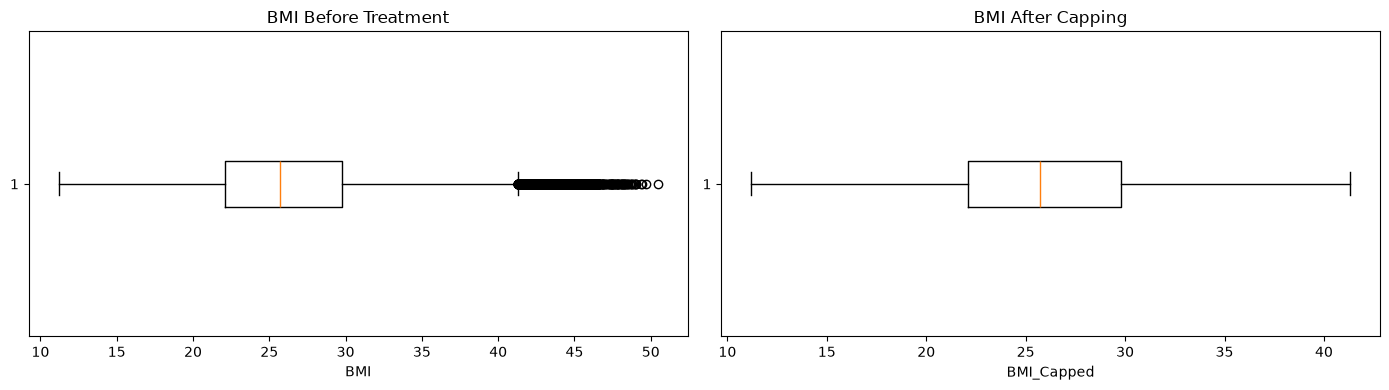

In [43]:
# Boxplot before and after BMI outlier treatment

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before treatment
axes[0].boxplot(df["BMI"], vert=False)
axes[0].set_title("BMI Before Treatment")
axes[0].set_xlabel("BMI")

# After treatment
axes[1].boxplot(df_outlier_treated["BMI_Capped"], vert=False)
axes[1].set_title("BMI After Capping")
axes[1].set_xlabel("BMI_Capped")

plt.tight_layout()
plt.show()

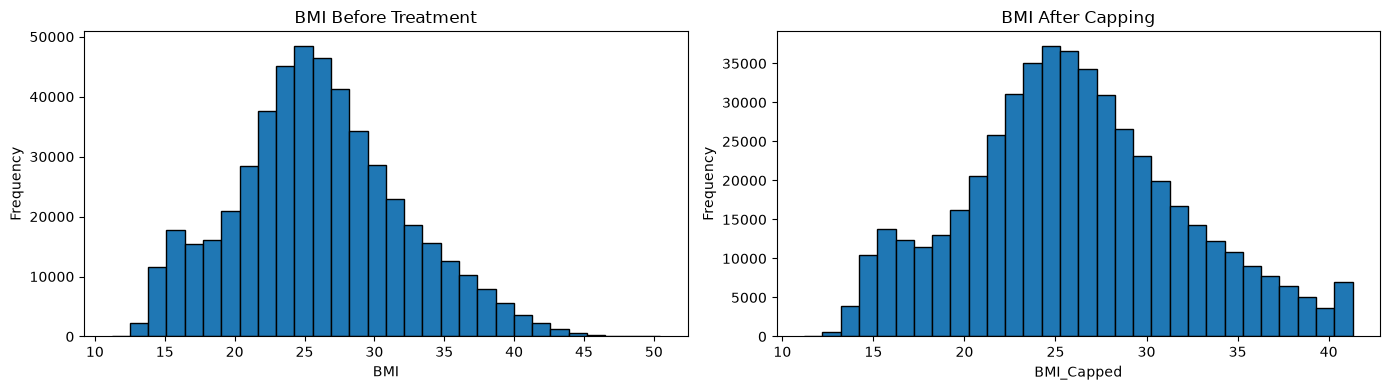

In [44]:
# Histogram before and after BMI outlier treatment

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before treatment
axes[0].hist(df["BMI"], bins=30, edgecolor="black")
axes[0].set_title("BMI Before Treatment")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Frequency")

# After treatment
axes[1].hist(df_outlier_treated["BMI_Capped"], bins=30, edgecolor="black")
axes[1].set_title("BMI After Capping")
axes[1].set_xlabel("BMI_Capped")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [45]:
# Replace BMI with the treated version for the next steps

# Save the original BMI values
df["BMI_Original"] = df["BMI"]

# Replace BMI with the capped BMI values
df["BMI"] = df_outlier_treated["BMI_Capped"]

# Remove temporary columns if they exist
df.drop(columns=["BMI_Zscore"], inplace=True, errors="ignore")
df_outlier_treated.drop(columns=["BMI_Capped"], inplace=True, errors="ignore")

print("BMI column now contains the capped values.")

# Compare BMI before and after replacement
display(df[["BMI_Original", "BMI"]].describe())

BMI column now contains the capped values.


,BMI_Original,BMI
count,496362.000000,496362.000000
mean,26.038696,26.024136
std,6.056667,6.016463
min,11.194870,11.194870
25%,22.089613,22.089613
50%,25.699361,25.699361
75%,29.778993,29.778993
max,50.445105,41.313062


##  Scaling Numerical Features


In [46]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create a copy of the dataset for scaling
df_scaled = df.copy()

# Numerical features
numerical_features = [
    "age",
    "BMI",
    "fasting_glucose",
    "HbA1c",
    "insulin",
    "triglycerides",
    "blood_pressure",
    "cholesterol_ratio"
]

# Initialize the scaler
scaler = StandardScaler()

# Apply Standard Scaling
df_scaled[numerical_features] = scaler.fit_transform(
    df_scaled[numerical_features]
)

print("Scaling completed successfully.")

display(df_scaled.head())

display(df_scaled[numerical_features].describe().round(2))

Scaling completed successfully.


,patient_id,age,gender,BMI,fasting_glucose,HbA1c,insulin,HOMA_IR,triglycerides,HDL,LDL,blood_pressure,physical_activity,Insulin_Resistance,gender_encoded,physical_activity_encoded,cholesterol_ratio,BMI_Original
0,1,-1.832304,Male,-0.551598,-0.490338,-0.545501,-1.540224,1.671935,-0.062804,38.688426,146.210743,1.314216,medium,0,1,1,0.086072,22.705471
1,1,-1.768818,Male,-0.636918,-0.654349,-0.463742,-1.493100,2.082398,-0.279447,38.421221,134.459133,-0.228862,medium,0,1,1,-0.173341,22.192149
2,1,-1.705333,Male,-0.519000,-0.705924,-0.406676,-1.230170,2.698112,0.048278,25.085364,92.051616,-1.051877,medium,0,1,1,-0.015669,22.901595
3,1,-1.641848,Male,-0.047992,-0.503126,-0.307548,-1.288799,3.040924,-1.144046,21.472752,104.451246,0.519604,medium,1,1,1,1.092971,25.735394
4,1,-1.578362,Male,-0.000923,-0.384891,-0.435025,-1.074238,3.573753,0.451799,22.834199,128.345299,-0.238762,medium,1,1,1,1.794796,26.018584


,age,BMI,fasting_glucose,HbA1c,insulin,triglycerides,blood_pressure,cholesterol_ratio
count,496362.00,496362.00,496362.00,496362.00,496362.00,496362.00,496362.00,496362.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.21,-2.46,-1.10,-2.55,-2.13,-4.29,-3.47,-2.35
25%,-0.82,-0.65,-0.75,-0.71,-0.84,-0.68,-0.68,-0.70
50%,0.01,-0.05,-0.29,-0.29,-0.08,-0.00,-0.00,-0.18
75%,0.77,0.62,0.52,0.51,0.90,0.67,0.67,0.49
max,2.29,2.54,3.63,4.81,1.51,4.76,3.95,7.22


##   Choosing Columns for Training and Testing

In [47]:
# Choose feature columns for training

feature_columns = [
    "age",
    "gender_encoded",
    "BMI",
    "fasting_glucose",
    "HbA1c",
    "insulin",
    "triglycerides",
    "blood_pressure",
    "physical_activity_encoded",
    "cholesterol_ratio"
]

target_column = "Insulin_Resistance"

X = df[feature_columns]
y = df[target_column]

print("Feature columns:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['age', 'gender_encoded', 'BMI', 'fasting_glucose', 'HbA1c', 'insulin', 'triglycerides', 'blood_pressure', 'physical_activity_encoded', 'cholesterol_ratio']

Target column:
Insulin_Resistance

X shape: (496362, 10)
y shape: (496362,)


In [48]:
# Preview X and y

display(X.head())
display(y.head())

,age,gender_encoded,BMI,fasting_glucose,HbA1c,insulin,triglycerides,blood_pressure,physical_activity_encoded,cholesterol_ratio
0,25,1,22.705471,93.193330,4.716758,8.183787,204.377524,157.355796,1,3.779186
1,26,1,22.192149,86.949074,4.827949,8.676000,198.232672,132.386041,1,3.499606
2,27,1,22.901595,84.985529,4.905558,11.422285,207.528255,119.068184,1,3.669535
3,28,1,25.735394,92.706466,5.040370,10.809908,173.709192,144.497555,1,4.864362
4,29,1,26.018584,97.207901,4.867005,13.050991,218.973728,132.225836,1,5.620749


0    0
1    0
2    0
3    1
4    1
Name: Insulin_Resistance, dtype: int64

###  Train-Test Split Idea


In [49]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature set shape: (397089, 10)
Testing feature set shape: (99273, 10)
Training target shape: (397089,)
Testing target shape: (99273,)


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression Pipeline
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report")
print(classification_report(y_test, logistic_predictions))

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.96      0.81     15578
           1       0.99      0.92      0.96     83695

    accuracy                           0.93     99273
   macro avg       0.85      0.94      0.88     99273
weighted avg       0.95      0.93      0.93     99273



In [52]:
# Calculate Logistic Regression evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(y_test, logistic_predictions, zero_division=0),
    "Recall": recall_score(y_test, logistic_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, logistic_predictions, zero_division=0)
}

pd.DataFrame([logistic_metrics], index=["Logistic Regression"])

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.929971,0.99205,0.924344,0.957001


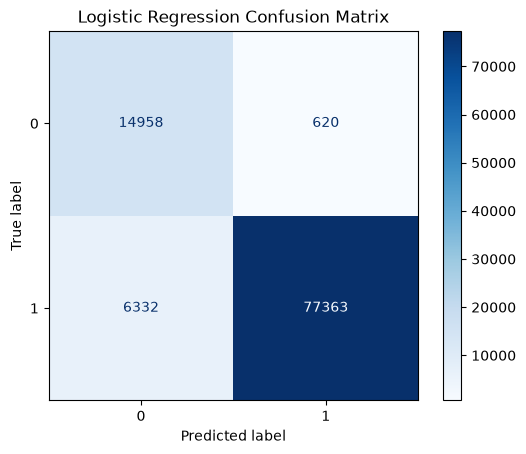

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

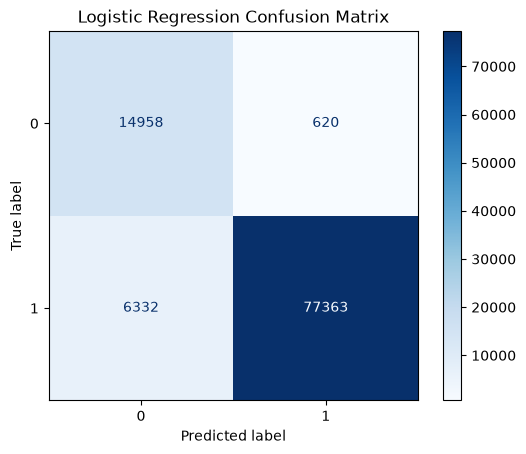

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    cmap="Blues",
    values_format="d"   # يعرض الأرقام كأعداد صحيحة
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Predictions
decision_tree_predictions = decision_tree_model.predict(X_test)
decision_tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, decision_tree_predictions, zero_division=0))

# Evaluation metrics
decision_tree_metrics = {
    "Accuracy": accuracy_score(y_test, decision_tree_predictions),
    "Precision": precision_score(y_test, decision_tree_predictions, zero_division=0),
    "Recall": recall_score(y_test, decision_tree_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, decision_tree_predictions, zero_division=0)
}

display(pd.DataFrame([decision_tree_metrics], index=["Decision Tree"]))

# Tree information
print("Actual tree depth:", decision_tree_model.get_depth())
print("Number of leaf nodes:", decision_tree_model.get_n_leaves())

              precision    recall  f1-score   support

           0       0.69      0.97      0.81     15578
           1       0.99      0.92      0.96     83695

    accuracy                           0.93     99273
   macro avg       0.84      0.95      0.88     99273
weighted avg       0.95      0.93      0.93     99273



,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.927402,0.994172,0.919278,0.95526


Actual tree depth: 8
Number of leaf nodes: 232


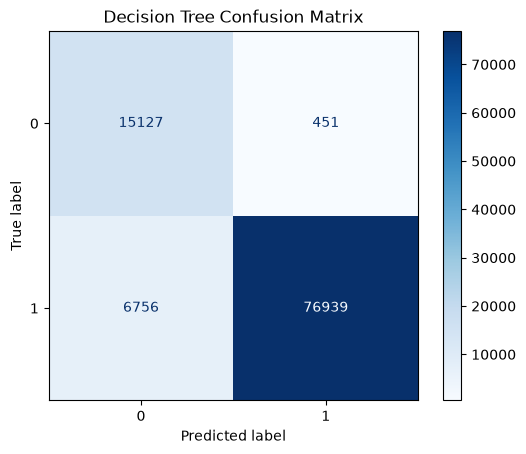

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_predictions,
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Predictions
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, random_forest_predictions, zero_division=0))

# Evaluation metrics
random_forest_metrics = {
    "Accuracy": accuracy_score(y_test, random_forest_predictions),
    "Precision": precision_score(y_test, random_forest_predictions, zero_division=0),
    "Recall": recall_score(y_test, random_forest_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, random_forest_predictions, zero_division=0)
}

display(pd.DataFrame([random_forest_metrics], index=["Random Forest"]))

# Model information
print("Number of trained trees:", len(random_forest_model.estimators_))
print("Maximum tree depth:", max(tree.get_depth() for tree in random_forest_model.estimators_))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81     15578
           1       0.99      0.92      0.96     83695

    accuracy                           0.93     99273
   macro avg       0.84      0.95      0.88     99273
weighted avg       0.95      0.93      0.93     99273



,Accuracy,Precision,Recall,F1 Score
Random Forest,0.928037,0.99479,0.919458,0.955642


Number of trained trees: 200
Maximum tree depth: 8


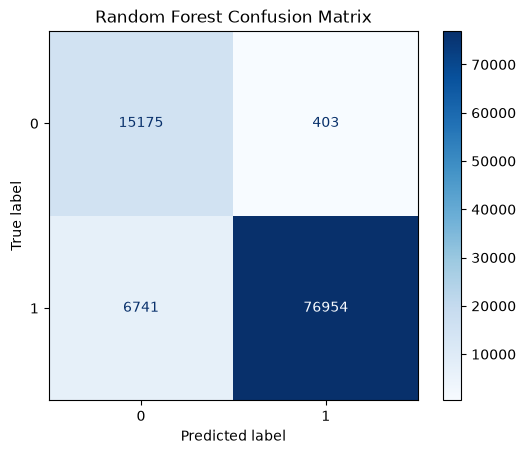

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create KNN model
knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

# Train the model
knn_model.fit(X_train, y_train)

# Predictions
knn_predictions = knn_model.predict(X_test)
knn_probabilities = knn_model.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, knn_predictions, zero_division=0))

# Evaluation metrics
knn_metrics = {
    "Accuracy": accuracy_score(y_test, knn_predictions),
    "Precision": precision_score(y_test, knn_predictions, zero_division=0),
    "Recall": recall_score(y_test, knn_predictions, zero_division=0),
    "F1 Score": f1_score(y_test, knn_predictions, zero_division=0)
}

display(pd.DataFrame([knn_metrics], index=["KNN"]))

# Model information
print("Number of stored training samples:", X_train.shape[0])
print("Number of neighbors:", knn_model.named_steps["model"].n_neighbors)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82     15578
           1       0.97      0.97      0.97     83695

    accuracy                           0.94     99273
   macro avg       0.89      0.89      0.89     99273
weighted avg       0.94      0.94      0.94     99273



,Accuracy,Precision,Recall,F1 Score
KNN,0.944335,0.967065,0.966904,0.966985


Number of stored training samples: 397089
Number of neighbors: 7


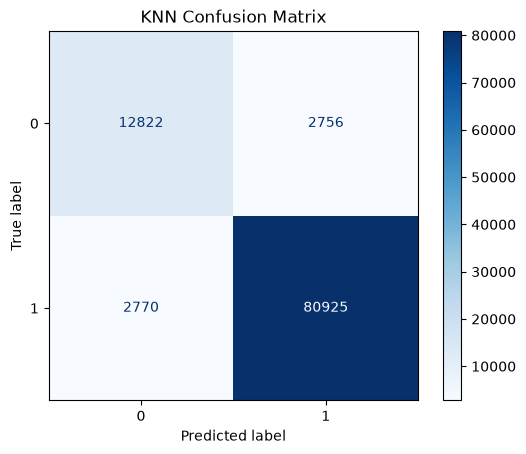

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    cmap="Blues",
    values_format="d"
)

plt.title("KNN Confusion Matrix")
plt.show()

In [61]:
from sklearn.metrics import accuracy_score

train_pred = logistic_model.predict(X_train)
test_pred = logistic_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9280262107487238
Test Accuracy : 0.9299708883583653


In [62]:
from sklearn.metrics import accuracy_score

train_pred = decision_tree_model.predict(X_train)
test_pred = decision_tree_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9269886599729532
Test Accuracy : 0.9274022140964814


In [63]:
train_pred = random_forest_model.predict(X_train)
test_pred = random_forest_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9270692464409742
Test Accuracy : 0.9280368277376527


In [64]:
train_pred = knn_model.predict(X_train)
test_pred = knn_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9572942086031091
Test Accuracy : 0.944335317760116


###  Final Comparison Between Models


In [65]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_metrics["Accuracy"],
        "Precision": logistic_metrics["Precision"],
        "Recall": logistic_metrics["Recall"],
        "F1 Score": logistic_metrics["F1 Score"]
    },
    {
        "Model": "Decision Tree",
        "Accuracy": decision_tree_metrics["Accuracy"],
        "Precision": decision_tree_metrics["Precision"],
        "Recall": decision_tree_metrics["Recall"],
        "F1 Score": decision_tree_metrics["F1 Score"]
    },
    {
        "Model": "Random Forest",
        "Accuracy": random_forest_metrics["Accuracy"],
        "Precision": random_forest_metrics["Precision"],
        "Recall": random_forest_metrics["Recall"],
        "F1 Score": random_forest_metrics["F1 Score"]
    },
    {
        "Model": "KNN",
        "Accuracy": knn_metrics["Accuracy"],
        "Precision": knn_metrics["Precision"],
        "Recall": knn_metrics["Recall"],
        "F1 Score": knn_metrics["F1 Score"]
    }
])

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.944335,0.967065,0.966904,0.966985
1,Logistic Regression,0.929971,0.992050,0.924344,0.957001
2,Random Forest,0.928037,0.994790,0.919458,0.955642
3,Decision Tree,0.927402,0.994172,0.919278,0.955260


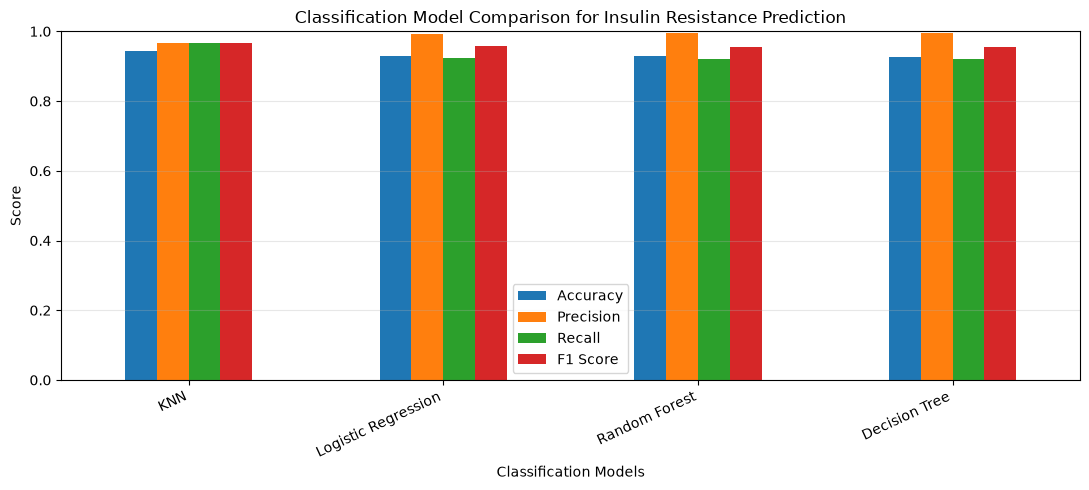

In [66]:
import matplotlib.pyplot as plt

comparison_plot = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Classification Model Comparison for Insulin Resistance Prediction")
plt.xlabel("Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

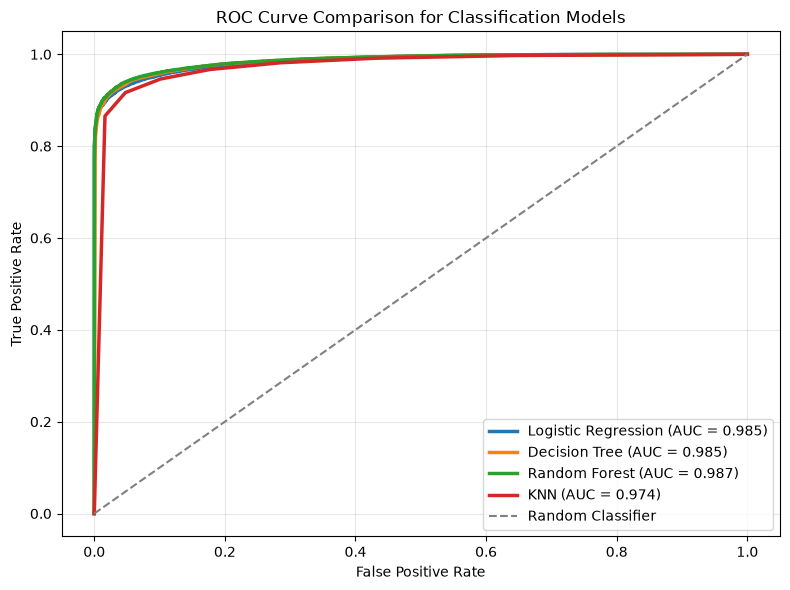

In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Store prediction probabilities for each model
model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": decision_tree_probabilities,
    "Random Forest": random_forest_probabilities,
    "KNN": knn_probabilities
}

plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    model_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Classification Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Save Train Model Logistic regression and install lib


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)


In [69]:
from pathlib import Path
from joblib import dump
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "research_grade_type2_logistic_regression_model.pkl"

dump(
    Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]).fit(X_train, y_train), 
    model_path
)

print("Saved model: Logistic Regression")
print(f"Model file path: {model_path}")

Saved model: Logistic Regression
Model file path: models\research_grade_type2_logistic_regression_model.pkl
